# TCCT S92A - Frozen Decoder Failure-Mechanism Audit

This is a post-hoc, read-only audit of the already revealed S92 blind failure. It is not a new blind test and it does not train, search, retune, or edit the TCCT core or either frozen model.

The audit verifies the immutable S92 archive, reproduces all frozen predictions, measures paired feature differences and class-support overlap, and performs explicitly off-manifold cardinality sensitivity probes against the unchanged classifier. Those probes diagnose decoder dependence only; they are not realizable-world counterfactual evidence.

Run **Kernel -> Restart Kernel and Run All Cells**. Expected runtime is well under two minutes because graph propagation is not rerun.


In [2045]:
ClearAll["Global`*"];
$HistoryLength=0;
<|"WolframVersion"->$Version,"SystemID"->$SystemID,
"ProcessorCount"->$ProcessorCount|>

<|WolframVersion -> 15.0.0 for Microsoft Windows (64-bit) (May 26, 2026), 
 
>   SystemID -> Windows-x86-64, ProcessorCount -> 10|>

Dataset[{<|Stage -> S92A-PREFLIGHT, Passed -> True, ArchivedWorlds -> 80, Pairs -> 40, 
 
>     ContinueTargets -> 40, StopTargets -> 40, 
 
>     S92Outcome -> S92_VALID_BLIND_FAILURE_DO_NOT_RETUNE, CoreLoaded -> False, 
 
>     TrainingRun -> False, RetuningApplied -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Passed, ArchivedWorlds, Pairs, 
 
>      ContinueTargets, StopTargets, S92Outcome, CoreLoaded, TrainingRun, 
 
>      RetuningApplied}, {TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
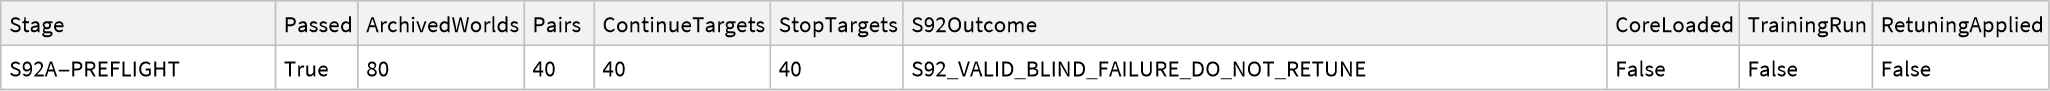

In [2052]:
ClearAll[FileSHA256Hex92A];
FileSHA256Hex92A[path_String]:=IntegerString[FileHash[path,"SHA256"],16,64];

projectDirectory92A=Directory[];
archivePath92A=FileNameJoin[{projectDirectory92A,"artifacts",
"TCCT_S92_FailureAuditWorlds.json"}];
archiveManifestPath92A=FileNameJoin[{projectDirectory92A,"artifacts",
"TCCT_S92_FailureAuditWorlds_Manifest.json"}];
decoderRuntimePath92A="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
decoderCandidatePath92A="E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
s92CertificatePath92A="E:/engine_wolf/TCCT_S92_BlindResultCertificate.json";
s92aCertificatePath="E:/engine_wolf/TCCT_S92A_FailureAuditCertificate.json";

expectedArchiveFileHash92A=
"dfe57246390b8bef52e2bf2bd98e01ba4fecc88091d269067bfb04f2b1b9d3bd";
expectedArchiveManifestFileHash92A=
"4c115bd1f45e407d6bc534a0236b65d150b37359e2afdad7bbe6fddc384ccb09";
expectedArchivePayloadHash92A=
"392721c25845bd8c4c40dd012fafef4ddb9936c68caae697ac5456d8a2bd07e7";
expectedDecoderCandidateFileHash92A=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedDecoderCandidateHash92A=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedDecoderRuntimeFileHash92A=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedS92CertificateFileHash92A=
"22cec6972285fe127e66d740bfdbbf27fbabaa097cb24cc0bbc7196da004a40b";
expectedS92ProtocolHash92A=
"4e7117970c3e5c4315fb4953364b632404566258a718c7807c8819ba3d30b6bb";
expectedS92TestDefinitionHash92A=
"3f072d5e37942fd007dd5b6fa73319d47da23e41b61ca05486fccc040f2b4904";
expectedS92BlindResultHash92A=
"a715ad1366f300a3e149c9f1df83c8e81744a7583678482900ed8736e4fc2273";

requiredFiles92A={archivePath92A,archiveManifestPath92A,
decoderRuntimePath92A,decoderCandidatePath92A,s92CertificatePath92A};
If[!And@@(FileExistsQ/@requiredFiles92A),
Print["S92A aborted: one or more locked inputs are missing."];
Dataset[AssociationThread[requiredFiles92A,FileExistsQ/@requiredFiles92A]];
Abort[]];
If[FileExistsQ[s92aCertificatePath],
Print["S92A aborted: a prior audit certificate already exists. Preserve it."];
Print[s92aCertificatePath];Abort[]];

archiveFileHashBefore92A=FileSHA256Hex92A[archivePath92A];
archiveManifestFileHashBefore92A=FileSHA256Hex92A[archiveManifestPath92A];
decoderCandidateFileHashBefore92A=FileSHA256Hex92A[decoderCandidatePath92A];
decoderRuntimeFileHashBefore92A=FileSHA256Hex92A[decoderRuntimePath92A];
s92CertificateFileHashBefore92A=FileSHA256Hex92A[s92CertificatePath92A];

archive92A=Quiet@Check[Import[archivePath92A,"RawJSON"],$Failed];
archiveManifest92A=Quiet@Check[Import[archiveManifestPath92A,"RawJSON"],$Failed];
s92Certificate92A=Quiet@Check[Import[s92CertificatePath92A,"RawJSON"],$Failed];
If[!AssociationQ[archive92A]||!AssociationQ[archiveManifest92A]||
!AssociationQ[s92Certificate92A],
Print["S92A aborted: a locked JSON input could not be imported."];Abort[]];

Get[decoderRuntimePath92A];
decoder92A=Quiet@Check[TCCTLoadFrozenDecoderS87D[decoderCandidatePath92A],$Failed];
If[!AssociationQ[decoder92A],
Print["S92A aborted: frozen S87D decoder integrity check failed."];Abort[]];

rows92A=Lookup[archive92A,"Rows",$Failed];
vectors92A=If[ListQ[rows92A],Lookup[rows92A,"FeatureVector",$Failed],$Failed];
targets92A=If[ListQ[rows92A],Lookup[rows92A,"Target",$Failed],$Failed];
archivedPredictions92A=If[ListQ[rows92A],Lookup[rows92A,"Prediction",$Failed],$Failed];
classifier92A=Lookup[decoder92A,"Classifier",$Failed];
featureNames92A=TCCTFeatureNamesS87D[];

preflightPassed92A=And[
SameQ[archiveFileHashBefore92A,expectedArchiveFileHash92A],
SameQ[archiveManifestFileHashBefore92A,expectedArchiveManifestFileHash92A],
SameQ[decoderCandidateFileHashBefore92A,expectedDecoderCandidateFileHash92A],
SameQ[decoderRuntimeFileHashBefore92A,expectedDecoderRuntimeFileHash92A],
SameQ[s92CertificateFileHashBefore92A,expectedS92CertificateFileHash92A],
SameQ[Lookup[archive92A,"ArchivePayloadHash",Missing[]],expectedArchivePayloadHash92A],
SameQ[Lookup[archiveManifest92A,"ArchivePayloadHash",Missing[]],expectedArchivePayloadHash92A],
SameQ[Lookup[archive92A,"SourceProtocolHash",Missing[]],expectedS92ProtocolHash92A],
SameQ[Lookup[archive92A,"SourceTestDefinitionHash",Missing[]],
expectedS92TestDefinitionHash92A],
SameQ[Lookup[archive92A,"SourceBlindResultHash",Missing[]],
expectedS92BlindResultHash92A],
SameQ[Lookup[s92Certificate92A,"ProtocolHash",Missing[]],expectedS92ProtocolHash92A],
SameQ[Lookup[s92Certificate92A,"TestDefinitionHash",Missing[]],
expectedS92TestDefinitionHash92A],
SameQ[Lookup[s92Certificate92A,"BlindResultHash",Missing[]],
expectedS92BlindResultHash92A],
SameQ[Lookup[s92Certificate92A,"Outcome",Missing[]],
"S92_VALID_BLIND_FAILURE_DO_NOT_RETUNE"],
TrueQ[Lookup[s92Certificate92A,"TestValidityPassed",False]],
SameQ[Lookup[decoder92A,"CandidateHash",Missing[]],expectedDecoderCandidateHash92A],
SameQ[Lookup[archive92A,"SourceCandidateHash",Missing[]],expectedDecoderCandidateHash92A],
ListQ[rows92A],SameQ[Length[rows92A],80],
ListQ[vectors92A],SameQ[Length[vectors92A],80],
And@@(VectorQ[#,IntegerQ]&&Length[#]===27&/@vectors92A),
SameQ[Counts[targets92A],<|"Continue"->40,"Stop"->40|>],
SameQ[DeleteDuplicates[Lookup[rows92A,"Cardinality"]],{{1,1,0}}],
SameQ[Length[featureNames92A],27],
And@@(MemberQ[{"Continue","Stop"},#]&/@archivedPredictions92A),
Head[classifier92A]===ClassifierFunction
];
If[!TrueQ[preflightPassed92A],
Print["S92A aborted: locked-input preflight failed."];Abort[]];

Dataset[{<|"Stage"->"S92A-PREFLIGHT","Passed"->preflightPassed92A,
"ArchivedWorlds"->Length[rows92A],"Pairs"->40,
"ContinueTargets"->Count[targets92A,"Continue"],
"StopTargets"->Count[targets92A,"Stop"],
"S92Outcome"->s92Certificate92A["Outcome"],
"CoreLoaded"->False,"TrainingRun"->False,"RetuningApplied"->False|>}]

Dataset[{<|Stage -> S92A, Name -> FailureMechanismAudit, 
 
>     EvaluationType -> PostHocLockedS92FailureAudit, BlindTest -> False, 
 
>     S92ResultsAlreadyRevealed -> True, 
 
>     Purpose -> LocateFrozenDecoderFailureWithoutChangingModelOrCore, 
 
>     ArchiveHash -> dfe57246390b8bef52e2bf2bd98e01ba4fecc88091d269067bfb04f2b1b9d3bd, 
 
>     ArchivePayloadHash -> 
 
>      392721c25845bd8c4c40dd012fafef4ddb9936c68caae697ac5456d8a2bd07e7, 
 
>     SourceS92ProtocolHash -> 
 
>      4e7117970c3e5c4315fb4953364b632404566258a718c7807c8819ba3d30b6bb, 
 
>     SourceS92TestDefinitionHash -> 
 
>      3f072d5e37942fd007dd5b6fa73319d47da23e41b61ca05486fccc040f2b4904, 
 
>     SourceS92BlindResultHash -> 
 
>      a715ad1366f300a3e149c9f1df83c8e81744a7583678482900ed8736e4fc2273, 
 
>     FrozenCandidateHash -> 
 
>      703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     FeatureDimensions -> 27, PairedWorlds -> 40, PairKey -> {Topology, Depth, Answer}, 
 
>     CardinalityPositions -> {1, 2, 18}, 
 
>     CardinalityProbeType -> SyntheticOffManifoldBlackBoxSensitivityOnly, 
 
>     CardinalityProbes -> 
 
>      {<|Probe -> Original, Cardinality -> {1, 1, 0}, OffManifold -> False|>, 
 
>       <|Probe -> ObservationCountOnly2, Cardinality -> {2, 1, 0}, 
 
>        OffManifold -> True|>, <|Probe -> DistinctCodeCountOnly2, 
 
>        Cardinality -> {1, 2, 0}, OffManifold -> True|>, 
 
>       <|Probe -> PairCountOnly1, Cardinality -> {1, 1, 1}, OffManifold -> True|>, 
 
>       <|Probe -> ObservationAndDistinct2, Cardinality -> {2, 2, 0}, 
 
>        OffManifold -> True|>, <|Probe -> ObservationAndPair, Cardinality -> {2, 1, 1}, 
 
>        OffManifold -> True|>, <|Probe -> DistinctAndPair, Cardinality -> {1, 2, 1}, 
 
>        OffManifold -> True|>, <|Probe -> S90StopLikeCardinality, 
 
>        Cardinality -> {2, 2, 1}, OffManifold -> True|>}, 
 
>     ProbeWarning -> 
 
>      Counterfactual vectors need not be realizable worlds and cannot establish causal\
 
>       semantics, TargetsUsedForDiagnosis -> True, TargetsUsedForTraining -> False, 
 
>     AllTrainableParametersFrozen -> True, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, HyperparameterSearchRun -> False, 
 
>     RetuningApplied -> False, CoreLoaded -> False, CoreEditApplied -> False, 
 
>     FrozenDecoderEditApplied -> False, FeatureRuntimeEditApplied -> False, 
 
>     CanonicalizerEditApplied -> False, InterventionRuleEditApplied -> False, 
 
>     DeduplicationMechanismEditApplied -> False, 
 
>     UndirectedFreezeMechanismEditApplied -> False, HistoricalBlindTestsRerun -> False, 
 
>     MayClaimNewBlindGeneralization -> False, MayUseS92AgainAsBlindTest -> False, 
 
>     ProtocolHash -> 57e107d467055654c89191a893799741877b4206936e3c7d3c3bd4f7dcc9e2d3|>}
 
>    , TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 
 
>     38], 1], <||>]
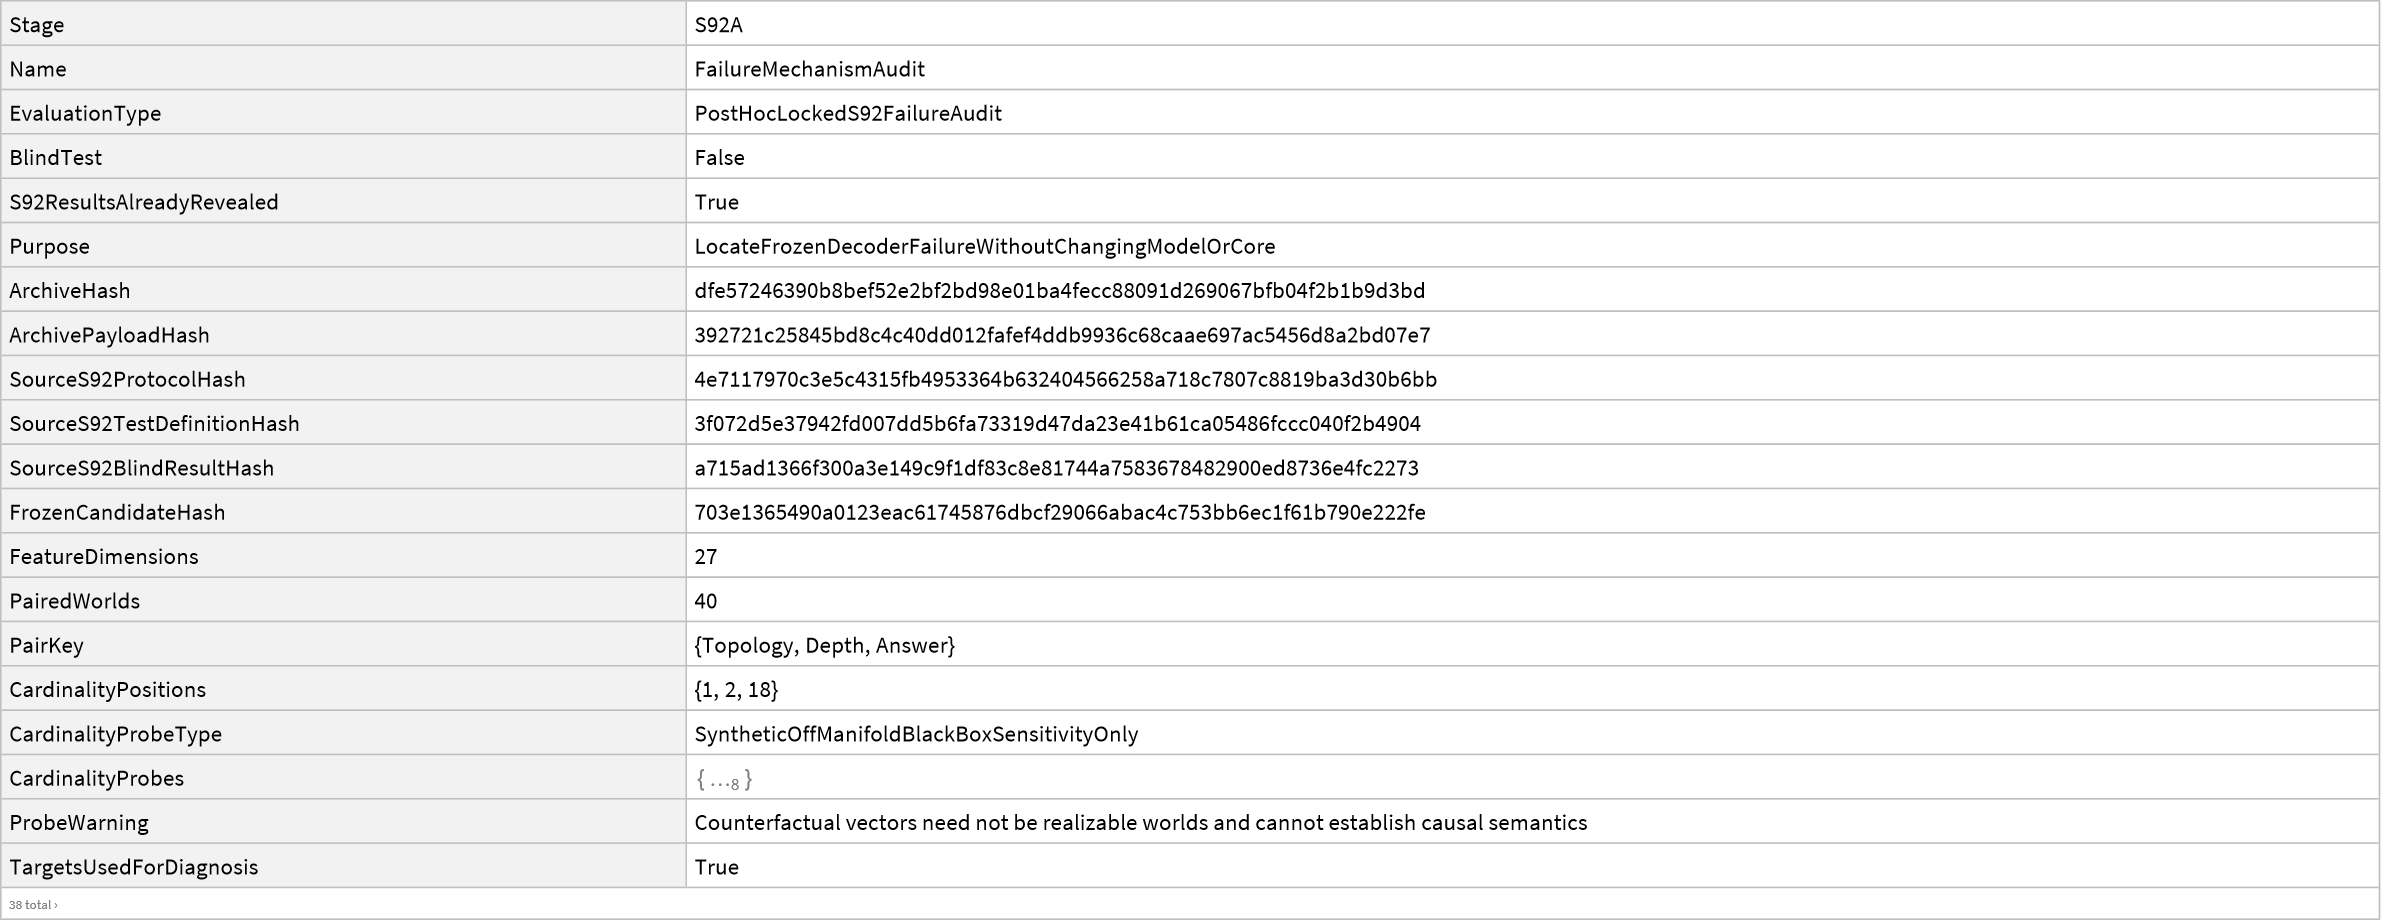

In [2099]:
ClearAll[PairKey92A,SetCardinality92A,FeatureAuditRow92A,
SupportAuditRow92A,InterventionAuditRow92A];

PairKey92A[row_Association]:={row["Topology"],row["Depth"],row["Answer"]};
continueRows92A=Select[rows92A,SameQ[#1["Target"],"Continue"]&];
stopRows92A=Select[rows92A,SameQ[#1["Target"],"Stop"]&];
pairKeys92A=PairKey92A/@continueRows92A;
pairedRows92A=Map[Function[key,<|
"Key"->key,
"Continue"->SelectFirst[continueRows92A,SameQ[PairKey92A[#],key]&,$Failed],
"Stop"->SelectFirst[stopRows92A,SameQ[PairKey92A[#],key]&,$Failed]
|>],pairKeys92A];

cardinalityProbeSpecs92A={
<|"Probe"->"Original","Cardinality"->{1,1,0},"OffManifold"->False|>,
<|"Probe"->"ObservationCountOnly2","Cardinality"->{2,1,0},"OffManifold"->True|>,
<|"Probe"->"DistinctCodeCountOnly2","Cardinality"->{1,2,0},"OffManifold"->True|>,
<|"Probe"->"PairCountOnly1","Cardinality"->{1,1,1},"OffManifold"->True|>,
<|"Probe"->"ObservationAndDistinct2","Cardinality"->{2,2,0},"OffManifold"->True|>,
<|"Probe"->"ObservationAndPair","Cardinality"->{2,1,1},"OffManifold"->True|>,
<|"Probe"->"DistinctAndPair","Cardinality"->{1,2,1},"OffManifold"->True|>,
<|"Probe"->"S90StopLikeCardinality","Cardinality"->{2,2,1},"OffManifold"->True|>
};

protocol92A=<|
"Stage"->"S92A","Name"->"FailureMechanismAudit",
"EvaluationType"->"PostHocLockedS92FailureAudit",
"BlindTest"->False,"S92ResultsAlreadyRevealed"->True,
"Purpose"->"LocateFrozenDecoderFailureWithoutChangingModelOrCore",
"ArchiveHash"->expectedArchiveFileHash92A,
"ArchivePayloadHash"->expectedArchivePayloadHash92A,
"SourceS92ProtocolHash"->expectedS92ProtocolHash92A,
"SourceS92TestDefinitionHash"->expectedS92TestDefinitionHash92A,
"SourceS92BlindResultHash"->expectedS92BlindResultHash92A,
"FrozenCandidateHash"->expectedDecoderCandidateHash92A,
"FeatureDimensions"->27,"PairedWorlds"->40,
"PairKey"->{"Topology","Depth","Answer"},
"CardinalityPositions"->{1,2,18},
"CardinalityProbeType"->"SyntheticOffManifoldBlackBoxSensitivityOnly",
"CardinalityProbes"->cardinalityProbeSpecs92A,
"ProbeWarning"->"Counterfactual vectors need not be realizable worlds and cannot establish causal semantics",
"TargetsUsedForDiagnosis"->True,
"TargetsUsedForTraining"->False,
"AllTrainableParametersFrozen"->True,
"TrainingRun"->False,"CandidateSearchRun"->False,
"HyperparameterSearchRun"->False,"RetuningApplied"->False,
"CoreLoaded"->False,"CoreEditApplied"->False,
"FrozenDecoderEditApplied"->False,
"FeatureRuntimeEditApplied"->False,
"CanonicalizerEditApplied"->False,
"InterventionRuleEditApplied"->False,
"DeduplicationMechanismEditApplied"->False,
"UndirectedFreezeMechanismEditApplied"->False,
"HistoricalBlindTestsRerun"->False,
"MayClaimNewBlindGeneralization"->False,
"MayUseS92AgainAsBlindTest"->False
|>;
protocolHashBeforeAudit92A=Hash[Normal[protocol92A],"SHA256","HexString"];
Dataset[{Append[protocol92A,"ProtocolHash"->protocolHashBeforeAudit92A]}]

Dataset[{<|FreshPredictionsMatchArchive -> True, OriginalPredictedContinue -> 80, 
 
>     OriginalPredictedStop -> 0, PairedRowsValid -> True, 
 
>     CardinalityPairsMatched -> 40, FullVectorPairsDifferent -> 40, 
 
>     ExactCoordinateSupportDisjoint -> True, 
 
>     CardinalityGateSensitivityObserved -> True, 
 
>     Diagnosis -> 
 
>      FROZEN_DECODER_CARDINALITY_GATE_DOMINATES_AVAILABLE_RELATIONAL_SIGNAL|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{FreshPredictionsMatchArchive, 
 
>      OriginalPredictedContinue, OriginalPredictedStop, PairedRowsValid, 
 
>      CardinalityPairsMatched, FullVectorPairsDifferent, 
 
>      ExactCoordinateSupportDisjoint, CardinalityGateSensitivityObserved, Diagnosis}, 
 
>     {TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String]}], 1], <||>]
Dataset[{<|FeatureGroup -> Cardinality, Positions -> {1, 2, 18}, 
 
>     ContinueSupportSize -> 1, StopSupportSize -> 1, SupportOverlapSize -> 1, 
 
>     SupportsDisjoint -> False|>, <|FeatureGroup -> ExactCoordinatePair, 
 
>     Positions -> {3, 4}, ContinueSupportSize -> 10, StopSupportSize -> 10, 
 
>     SupportOverlapSize -> 0, SupportsDisjoint -> True|>, 
 
>    <|FeatureGroup -> ModuloTriplet, Positions -> {11, 12, 13}, 
 
>     ContinueSupportSize -> 10, StopSupportSize -> 10, SupportOverlapSize -> 0, 
 
>     SupportsDisjoint -> True|>, <|FeatureGroup -> CoordinatesAndModulo, 
 
>     Positions -> {3, 4, 11, 12, 13}, ContinueSupportSize -> 10, StopSupportSize -> 10, 
 
>     SupportOverlapSize -> 0, SupportsDisjoint -> True|>, 
 
>    <|FeatureGroup -> UnaryRelationalFeatures, 
 
>     Positions -> {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, 
 
>     ContinueSupportSize -> 10, StopSupportSize -> 10, SupportOverlapSize -> 0, 
 
>     SupportsDisjoint -> True|>, <|FeatureGroup -> AllNonCardinalityFeatures, 
 
>     Positions -> 
 
>      {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 
 
>       26, 27}, ContinueSupportSize -> 10, StopSupportSize -> 10, 
 
>     SupportOverlapSize -> 0, SupportsDisjoint -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{FeatureGroup, Positions, ContinueSupportSize, 
 
>      StopSupportSize, SupportOverlapSize, SupportsDisjoint}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Vector[TypeSystem`Atom[Integer], 
 
>       TypeSystem`AnyLength], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean]}], 6], <||>]
Dataset[{<|Index -> 1, Feature -> ObservationCount, PairedDifferences -> 0, 
 
>     ContinueDistinctValues -> 1, StopDistinctValues -> 1, SupportOverlapValues -> 1, 
 
>     SupportsDisjoint -> False, RangesSeparated -> False, ContinueMin -> 1, 
 
>     ContinueMax -> 1, StopMin -> 1, StopMax -> 1|>, 
 
>    <|Index -> 2, Feature -> DistinctCodeCount, PairedDifferences -> 0, 
 
>     ContinueDistinctValues -> 1, StopDistinctValues -> 1, SupportOverlapValues -> 1, 
 
>     SupportsDisjoint -> False, RangesSeparated -> False, ContinueMin -> 1, 
 
>     ContinueMax -> 1, StopMin -> 1, StopMax -> 1|>, 
 
>    <|Index -> 3, Feature -> FirstCoordinateTotal, PairedDifferences -> 40, 
 
>     ContinueDistinctValues -> 8, StopDistinctValues -> 8, SupportOverlapValues -> 2, 
 
>     SupportsDisjoint -> False, RangesSeparated -> False, ContinueMin -> 2, 
 
>     ContinueMax -> 32, StopMin -> 5, StopMax -> 31|>, 
 
>    <|Index -> 4, Feature -> SecondCoordinateTotal, PairedDifferences -> 40, 
 
>     ContinueDistinctValues -> 9, StopDistinctValues -> 10, SupportOverlapValues -> 1, 
 
>     SupportsDisjoint -> False, RangesSeparated -> False, ContinueMin -> 3, 
 
>     ContinueMax -> 29, StopMin -> 1, StopMax -> 31|>, 
 
>    <|Ind
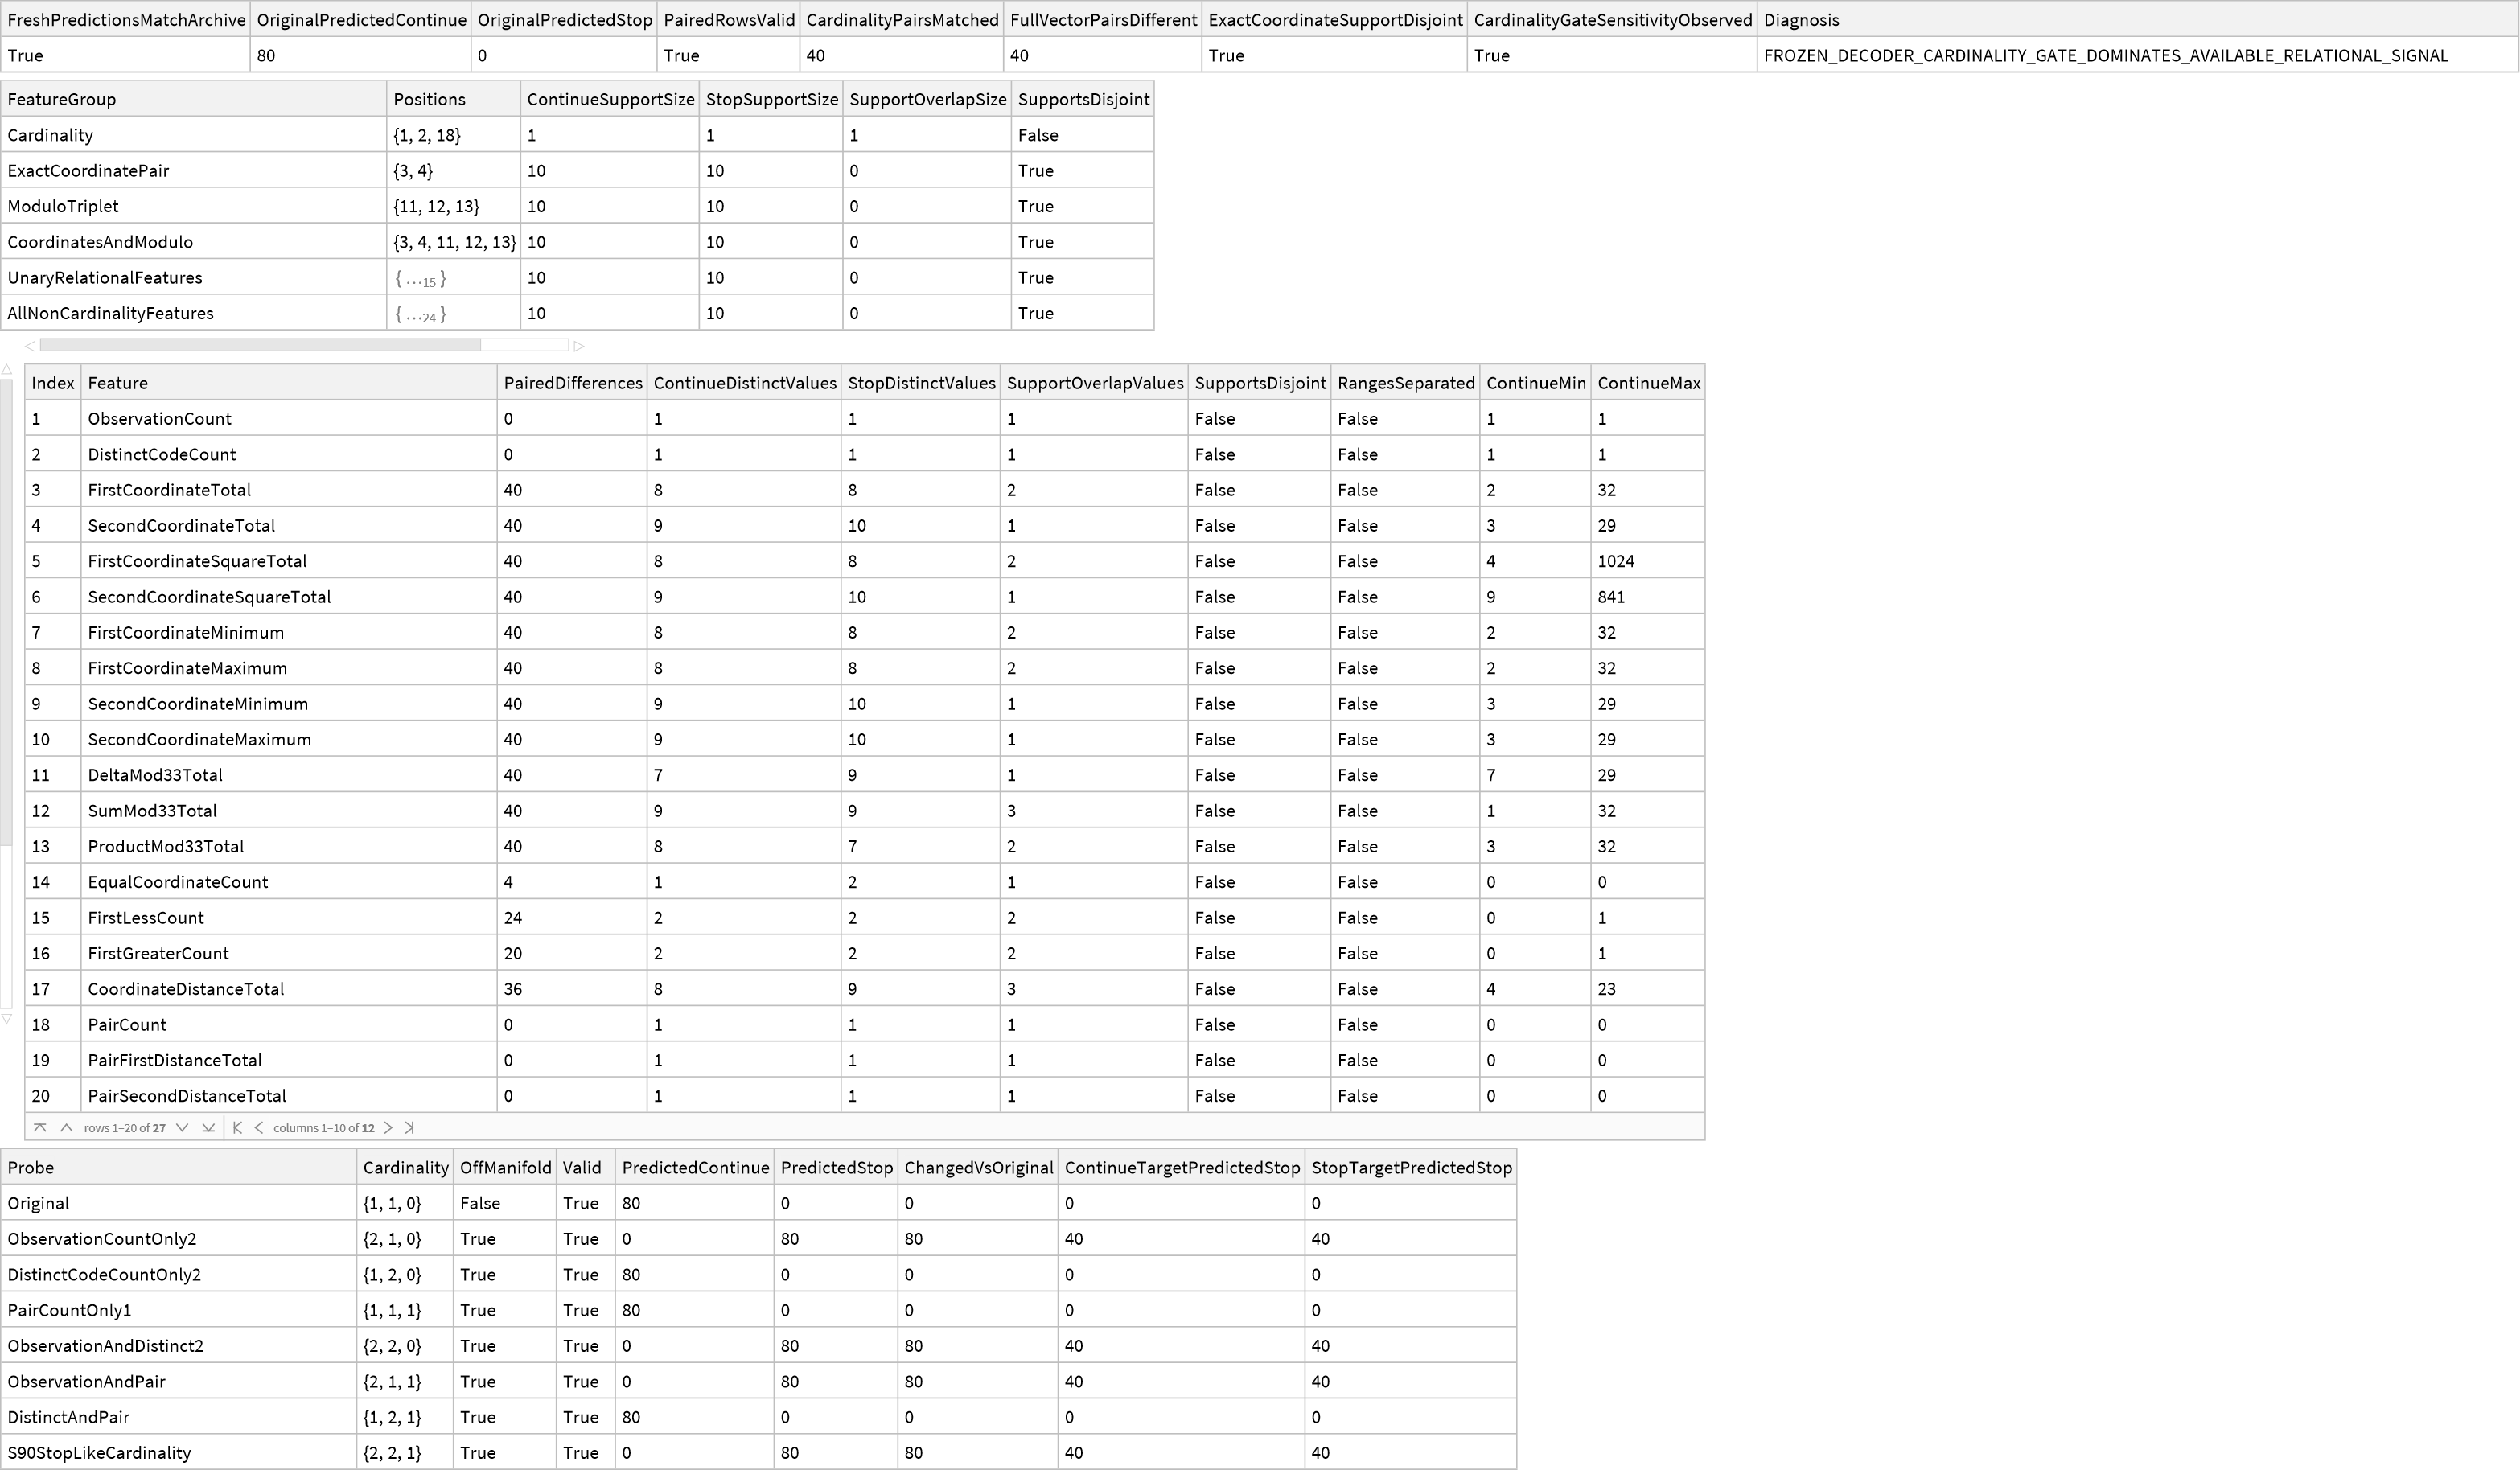

In [2113]:
freshPredictions92A=Quiet@Check[classifier92A/@vectors92A,$Failed];
freshPredictionsValid92A=ListQ[freshPredictions92A]&&
SameQ[Length[freshPredictions92A],80]&&
And@@(MemberQ[{"Continue","Stop"},#]&/@freshPredictions92A);
freshPredictionsMatchArchive92A=TrueQ[freshPredictionsValid92A]&&
SameQ[freshPredictions92A,archivedPredictions92A];

FeatureAuditRow92A[index_Integer]:=Module[
{continueValues,stopValues,pairedDifferent,continueSupport,stopSupport,overlap},
continueValues=Lookup[continueRows92A,"FeatureVector"][[All,index]];
stopValues=Lookup[stopRows92A,"FeatureVector"][[All,index]];
pairedDifferent=Count[pairedRows92A,pair_/;
pair["Continue"]["FeatureVector"][[index]]=!=
pair["Stop"]["FeatureVector"][[index]]];
continueSupport=DeleteDuplicates[continueValues];
stopSupport=DeleteDuplicates[stopValues];
overlap=Intersection[continueSupport,stopSupport];
<|"Index"->index,"Feature"->featureNames92A[[index]],
"PairedDifferences"->pairedDifferent,
"ContinueDistinctValues"->Length[continueSupport],
"StopDistinctValues"->Length[stopSupport],
"SupportOverlapValues"->Length[overlap],
"SupportsDisjoint"->SameQ[Length[overlap],0],
"RangesSeparated"->Or[Max[continueValues]<Min[stopValues],
Max[stopValues]<Min[continueValues]],
"ContinueMin"->Min[continueValues],"ContinueMax"->Max[continueValues],
"StopMin"->Min[stopValues],"StopMax"->Max[stopValues]|>
];
featureAuditRows92A=FeatureAuditRow92A/@Range[27];

SupportAuditRow92A[name_String,positions_List]:=Module[
{continueSupport,stopSupport,overlap},
continueSupport=DeleteDuplicates[Lookup[continueRows92A,"FeatureVector"][[All,positions]]];
stopSupport=DeleteDuplicates[Lookup[stopRows92A,"FeatureVector"][[All,positions]]];
overlap=Intersection[continueSupport,stopSupport];
<|"FeatureGroup"->name,"Positions"->positions,
"ContinueSupportSize"->Length[continueSupport],
"StopSupportSize"->Length[stopSupport],
"SupportOverlapSize"->Length[overlap],
"SupportsDisjoint"->SameQ[Length[overlap],0]|>
];
supportAuditRows92A={
SupportAuditRow92A["Cardinality",{1,2,18}],
SupportAuditRow92A["ExactCoordinatePair",{3,4}],
SupportAuditRow92A["ModuloTriplet",{11,12,13}],
SupportAuditRow92A["CoordinatesAndModulo",{3,4,11,12,13}],
SupportAuditRow92A["UnaryRelationalFeatures",Range[3,17]],
SupportAuditRow92A["AllNonCardinalityFeatures",Complement[Range[27],{1,2,18}]]
};

SetCardinality92A[vector_List,triplet_List]:=ReplacePart[vector,
{1->triplet[[1]],2->triplet[[2]],18->triplet[[3]]}];
InterventionAuditRow92A[spec_Association]:=Module[
{modified,predictions,valid,changed,continuePositions,stopPositions},
modified=SetCardinality92A[#,spec["Cardinality"]]&/@vectors92A;
predictions=Quiet@Check[classifier92A/@modified,$Failed];
valid=ListQ[predictions]&&SameQ[Length[predictions],80]&&
And@@(MemberQ[{"Continue","Stop"},#]&/@predictions);
If[!TrueQ[valid],Return[Join[spec,<|"Valid"->False,
"PredictedContinue"->0,"PredictedStop"->0,"ChangedVsOriginal"->80,
"ContinueTargetPredictedStop"->0,"StopTargetPredictedStop"->0|>]]];
changed=Count[MapThread[UnsameQ,{predictions,freshPredictions92A}],True];
continuePositions=Flatten@Position[targets92A,"Continue"];
stopPositions=Flatten@Position[targets92A,"Stop"];
Join[spec,<|"Valid"->True,
"PredictedContinue"->Count[predictions,"Continue"],
"PredictedStop"->Count[predictions,"Stop"],
"ChangedVsOriginal"->changed,
"ContinueTargetPredictedStop"->Count[predictions[[continuePositions]],"Stop"],
"StopTargetPredictedStop"->Count[predictions[[stopPositions]],"Stop"]|>]
];
cardinalityInterventionRows92A=InterventionAuditRow92A/@cardinalityProbeSpecs92A;

pairedRowsValid92A=And[
SameQ[Length[pairedRows92A],40],SameQ[Length[DeleteDuplicates[pairKeys92A]],40],
And@@Map[Function[pair,AssociationQ[pair["Continue"]]&&
AssociationQ[pair["Stop"]]&&
SameQ[PairKey92A[pair["Continue"]],PairKey92A[pair["Stop"]]]&&
SameQ[pair["Continue"]["Target"],"Continue"]&&
SameQ[pair["Stop"]["Target"],"Stop"]],pairedRows92A]
];
fullVectorPairedDifferences92A=Count[pairedRows92A,pair_/;
pair["Continue"]["FeatureVector"]=!=pair["Stop"]["FeatureVector"]];
cardinalityPairedMatches92A=Count[pairedRows92A,pair_/;
SameQ[pair["Continue"]["Cardinality"],pair["Stop"]["Cardinality"]]];
exactCoordinateSupportDisjoint92A=TrueQ[
SelectFirst[supportAuditRows92A,
SameQ[#1["FeatureGroup"],"ExactCoordinatePair"]&]["SupportsDisjoint"]];
originalProbe92A=First[cardinalityInterventionRows92A];
cardinalityProbeStopMaximum92A=Max[Lookup[
Rest[cardinalityInterventionRows92A],"PredictedStop"]];
cardinalityGateSensitivityObserved92A=cardinalityProbeStopMaximum92A>0;

diagnosis92A=Which[
!TrueQ[freshPredictionsMatchArchive92A],
"AUDIT_INVALID_FROZEN_PREDICTION_REPRODUCTION_FAILED",
!TrueQ[pairedRowsValid92A]||fullVectorPairedDifferences92A<40,
"AUDIT_INVALID_PAIR_STRUCTURE_FAILED",
SameQ[originalProbe92A["PredictedStop"],0]&&
TrueQ[exactCoordinateSupportDisjoint92A]&&
TrueQ[cardinalityGateSensitivityObserved92A],
"FROZEN_DECODER_CARDINALITY_GATE_DOMINATES_AVAILABLE_RELATIONAL_SIGNAL",
SameQ[originalProbe92A["PredictedStop"],0]&&
TrueQ[exactCoordinateSupportDisjoint92A],
"FROZEN_DECODER_BOUNDARY_DOES_NOT_USE_AVAILABLE_S92_RELATIONAL_SIGNAL",
True,
"FROZEN_DECODER_POSTHOC_FAILURE_REQUIRES_DEEPER_BOUNDARY_AUDIT"
];

Column[{
Dataset[{<|"FreshPredictionsMatchArchive"->freshPredictionsMatchArchive92A,
"OriginalPredictedContinue"->Count[freshPredictions92A,"Continue"],
"OriginalPredictedStop"->Count[freshPredictions92A,"Stop"],
"PairedRowsValid"->pairedRowsValid92A,
"CardinalityPairsMatched"->cardinalityPairedMatches92A,
"FullVectorPairsDifferent"->fullVectorPairedDifferences92A,
"ExactCoordinateSupportDisjoint"->exactCoordinateSupportDisjoint92A,
"CardinalityGateSensitivityObserved"->cardinalityGateSensitivityObserved92A,
"Diagnosis"->diagnosis92A|>}],
Dataset[supportAuditRows92A],
Dataset[featureAuditRows92A],
Dataset[cardinalityInterventionRows92A]
}]

Dataset[{<|Stage -> S92A, Name -> FailureMechanismAudit, 
 
>     EvaluationType -> PostHocLockedS92FailureAudit, BlindTest -> False, 
 
>     ProtocolHash -> 57e107d467055654c89191a893799741877b4206936e3c7d3c3bd4f7dcc9e2d3, 
 
>     ArchiveFileHash -> 
 
>      dfe57246390b8bef52e2bf2bd98e01ba4fecc88091d269067bfb04f2b1b9d3bd, 
 
>     ArchiveManifestFileHash -> 
 
>      4c115bd1f45e407d6bc534a0236b65d150b37359e2afdad7bbe6fddc384ccb09, 
 
>     ArchivePayloadHash -> 
 
>      392721c25845bd8c4c40dd012fafef4ddb9936c68caae697ac5456d8a2bd07e7, 
 
>     S92CertificateFileHash -> 
 
>      22cec6972285fe127e66d740bfdbbf27fbabaa097cb24cc0bbc7196da004a40b, 
 
>     S92BlindResultHash -> 
 
>      a715ad1366f300a3e149c9f1df83c8e81744a7583678482900ed8736e4fc2273, 
 
>     FrozenCandidateHash -> 
 
>      703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     FrozenCandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     FrozenRuntimeFileHash -> 
 
>      7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee, 
 
>     WorldsAudited -> 80, PairsAudited -> 40, FreshPredictionsMatchArchivedS92 -> True, 
 
>     OriginalPredictedContinue -> 80, OriginalPredictedStop -> 0, 
 
>     CardinalityPairsMatched -> 40, FullFeatureVectorPairsDifferent -> 40, 
 
>     ExactCoordinatePairSupportsDisjoint -> True, 
 
>     CardinalityGateSensitivityObserved -> True, 
 
>     MaximumStopPredictionsUnderCardinalityProbes -> 80, 
 
>     Diagnosis -> 
 
>      FROZEN_DECODER_CARDINALITY_GATE_DOMINATES_AVAILABLE_RELATIONAL_SIGNAL, 
 
>     AuditValidityPassed -> True, OriginalFrozenModelChanged -> False, 
 
>     FrozenDecoderChanged -> False, FeatureRuntimeChanged -> False, 
 
>     CoreLoaded -> False, CoreChanged -> False, CanonicalizerChanged -> False, 
 
>     InterventionCoreChanged -> False, DeduplicationMechanismChanged -> False, 
 
>     UndirectedFreezeMechanismChanged -> False, S92ArchiveChanged -> False, 
 
>     S92CertificateChanged -> False, TrainingRun -> False, CandidateSearchRun -> False, 
 
>     HyperparameterSearchRun -> False, RetuningApplied -> False, 
 
>     HistoricalBlindTestsRerun -> False, TargetsUsedForDiagnosisOnly -> True, 
 
>     OffManifoldProbesAreSensitivityEvidenceOnly -> True, 
 
>     MayClaimNewBlindGeneralization -> False, MayReuseS92AsBlind -> False, 
 
>     AuditResultHash -> 
 
>      976a850af3f591b8766f0aeb3439b70678b051e91ef0452c1df77dfebf0fd9f9, 
 
>     Outcome -> S92A_VALID_FAILURE_MECHANISM_AUDIT_COMPLETE, 
 
>     SuggestedNextStage -> 
 
>      S92B_TRAIN_CARDINALITY_MATCHED_RELATIONAL_DECODER_THEN_S93_NEW_BLIND|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 48], 
 
>    1], <||>]
Dataset[{<|FeatureGroup -> Cardinality, Positions -> {1, 2, 18}, 
 
>     ContinueSupportSize -> 1, StopSupportSize -> 1, SupportOverlapSize -> 1, 
 
>     SupportsDisjoint -> False|>, <|FeatureGroup -> ExactCoordinatePair, 
 
>     Positions -> {3, 4}, ContinueSupportSize -> 10, StopSupportSize -> 10, 
 
>     SupportOverlapSize -> 0, SupportsDisjoint -> True|>, 
 
>    <|FeatureGroup -> ModuloTriplet, Positions -> {11, 12, 13}, 
 
>     ContinueSupportSize -> 10, StopSupportSize -> 10, SupportOverlapSize -> 0, 
 
>     SupportsDisjoint -> True|>, <|FeatureGroup -> CoordinatesAndModulo, 
 
>     Positions -> {3, 4, 11, 12, 13}, ContinueSupportSize -> 10, StopSupportSize -> 10, 
 
>     SupportOverlapSize -> 0, SupportsDisjoint -> True|>, 
 
>    <|FeatureGroup -> UnaryRelationalFeatures, 
 
>     Positions -> {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, 
 
>     ContinueSupportSize -> 10, StopSupportSize -> 10, SupportOverlapSize -> 0, 
 
>     SupportsDisjoint -> True|>, <|FeatureGroup -> AllNonCardinalityFeatures, 
 
>     Positions -> 
 
>      {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 
 
>       26, 27}, ContinueSupportSize -> 10, StopSupportSize ->
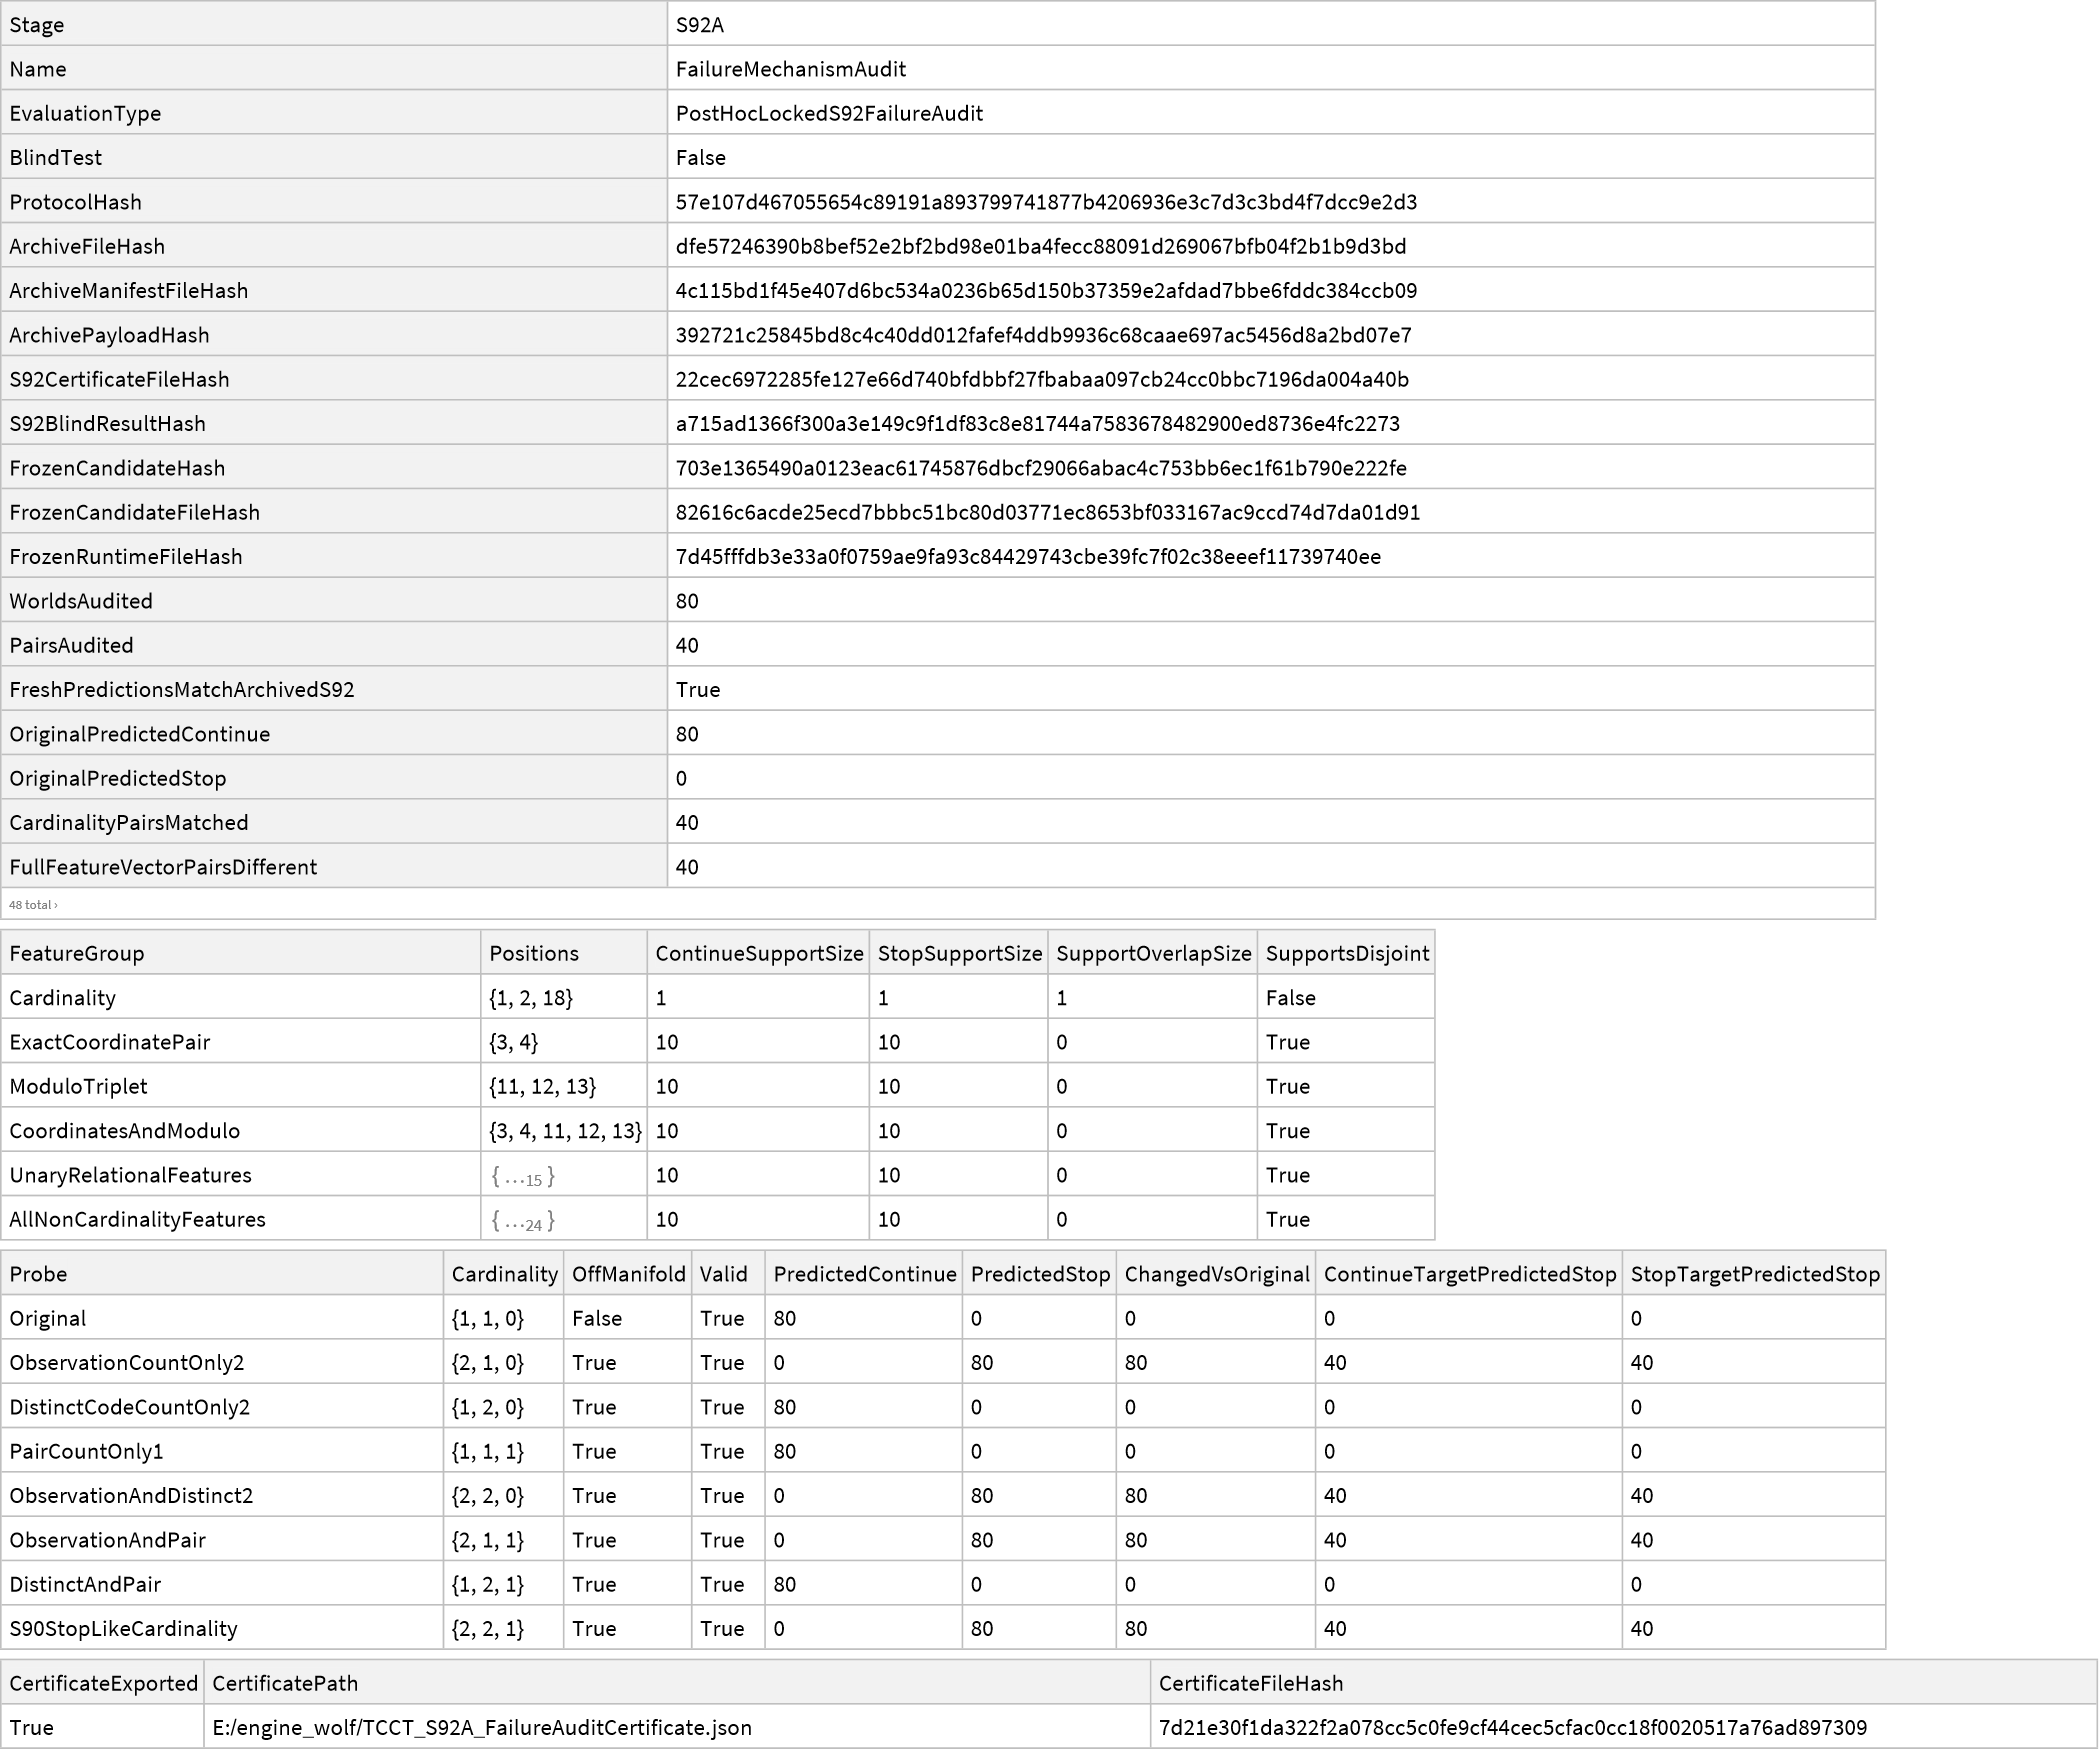

In [2132]:
protocolHashAfterAudit92A=Hash[Normal[protocol92A],"SHA256","HexString"];
archiveFileHashAfter92A=FileSHA256Hex92A[archivePath92A];
archiveManifestFileHashAfter92A=FileSHA256Hex92A[archiveManifestPath92A];
decoderCandidateFileHashAfter92A=FileSHA256Hex92A[decoderCandidatePath92A];
decoderRuntimeFileHashAfter92A=FileSHA256Hex92A[decoderRuntimePath92A];
s92CertificateFileHashAfter92A=FileSHA256Hex92A[s92CertificatePath92A];

allFeatureAuditRowsValid92A=And@@Map[Function[row,And[
Between[row["Index"],{1,27}],Between[row["PairedDifferences"],{0,40}],
row["ContinueDistinctValues"]>=1,row["StopDistinctValues"]>=1,
row["SupportOverlapValues"]>=0]],featureAuditRows92A];
allInterventionRowsValid92A=And@@(TrueQ[Lookup[#,"Valid",False]]&/@
cardinalityInterventionRows92A);

auditValidityPassed92A=And[
TrueQ[preflightPassed92A],TrueQ[freshPredictionsMatchArchive92A],
TrueQ[pairedRowsValid92A],SameQ[cardinalityPairedMatches92A,40],
SameQ[fullVectorPairedDifferences92A,40],
SameQ[Count[freshPredictions92A,"Continue"],80],
SameQ[Count[freshPredictions92A,"Stop"],0],
TrueQ[allFeatureAuditRowsValid92A],TrueQ[allInterventionRowsValid92A],
SameQ[protocolHashBeforeAudit92A,protocolHashAfterAudit92A],
SameQ[archiveFileHashBefore92A,archiveFileHashAfter92A],
SameQ[archiveManifestFileHashBefore92A,archiveManifestFileHashAfter92A],
SameQ[decoderCandidateFileHashBefore92A,decoderCandidateFileHashAfter92A],
SameQ[decoderRuntimeFileHashBefore92A,decoderRuntimeFileHashAfter92A],
SameQ[s92CertificateFileHashBefore92A,s92CertificateFileHashAfter92A]
];

auditPayload92A=<|
"Stage"->"S92A","Name"->"FailureMechanismAudit",
"EvaluationType"->"PostHocLockedS92FailureAudit","BlindTest"->False,
"ProtocolHash"->protocolHashAfterAudit92A,
"ArchiveFileHash"->archiveFileHashAfter92A,
"ArchiveManifestFileHash"->archiveManifestFileHashAfter92A,
"ArchivePayloadHash"->archive92A["ArchivePayloadHash"],
"S92CertificateFileHash"->s92CertificateFileHashAfter92A,
"S92BlindResultHash"->s92Certificate92A["BlindResultHash"],
"FrozenCandidateHash"->decoder92A["CandidateHash"],
"FrozenCandidateFileHash"->decoderCandidateFileHashAfter92A,
"FrozenRuntimeFileHash"->decoderRuntimeFileHashAfter92A,
"WorldsAudited"->Length[rows92A],"PairsAudited"->Length[pairedRows92A],
"FreshPredictionsMatchArchivedS92"->freshPredictionsMatchArchive92A,
"OriginalPredictedContinue"->Count[freshPredictions92A,"Continue"],
"OriginalPredictedStop"->Count[freshPredictions92A,"Stop"],
"CardinalityPairsMatched"->cardinalityPairedMatches92A,
"FullFeatureVectorPairsDifferent"->fullVectorPairedDifferences92A,
"ExactCoordinatePairSupportsDisjoint"->exactCoordinateSupportDisjoint92A,
"CardinalityGateSensitivityObserved"->cardinalityGateSensitivityObserved92A,
"MaximumStopPredictionsUnderCardinalityProbes"->cardinalityProbeStopMaximum92A,
"Diagnosis"->diagnosis92A,
"FeatureAudit"->featureAuditRows92A,
"FeatureGroupSupportAudit"->supportAuditRows92A,
"CardinalitySensitivityAudit"->cardinalityInterventionRows92A,
"AuditValidityPassed"->auditValidityPassed92A,
"OriginalFrozenModelChanged"->False,
"FrozenDecoderChanged"->!SameQ[decoderCandidateFileHashBefore92A,
decoderCandidateFileHashAfter92A],
"FeatureRuntimeChanged"->!SameQ[decoderRuntimeFileHashBefore92A,
decoderRuntimeFileHashAfter92A],
"CoreLoaded"->False,"CoreChanged"->False,
"CanonicalizerChanged"->False,"InterventionCoreChanged"->False,
"DeduplicationMechanismChanged"->False,
"UndirectedFreezeMechanismChanged"->False,
"S92ArchiveChanged"->!SameQ[archiveFileHashBefore92A,archiveFileHashAfter92A],
"S92CertificateChanged"->!SameQ[s92CertificateFileHashBefore92A,
s92CertificateFileHashAfter92A],
"TrainingRun"->False,"CandidateSearchRun"->False,
"HyperparameterSearchRun"->False,"RetuningApplied"->False,
"HistoricalBlindTestsRerun"->False,
"TargetsUsedForDiagnosisOnly"->True,
"OffManifoldProbesAreSensitivityEvidenceOnly"->True,
"MayClaimNewBlindGeneralization"->False,
"MayReuseS92AsBlind"->False
|>;
auditResultHash92A=Hash[Normal[auditPayload92A],"SHA256","HexString"];
cert92A=Join[auditPayload92A,<|
"AuditResultHash"->auditResultHash92A,
"Outcome"->If[TrueQ[auditValidityPassed92A],
"S92A_VALID_FAILURE_MECHANISM_AUDIT_COMPLETE",
"S92A_INVALID_AUDIT_DO_NOT_INTERPRET"],
"SuggestedNextStage"->If[TrueQ[auditValidityPassed92A],
"S92B_TRAIN_CARDINALITY_MATCHED_RELATIONAL_DECODER_THEN_S93_NEW_BLIND",
"S92AR_REPAIR_AUDIT_HARNESS_WITHOUT_MODEL_CHANGE"]|>];
certificateExportResult92A=Quiet@Check[
Export[s92aCertificatePath,cert92A,"RawJSON"],$Failed];
certificateExported92A=And[StringQ[certificateExportResult92A],
FileExistsQ[s92aCertificatePath]];

Column[{
Dataset[{KeyDrop[cert92A,{"FeatureAudit","FeatureGroupSupportAudit",
"CardinalitySensitivityAudit"}]}],
Dataset[supportAuditRows92A],
Dataset[cardinalityInterventionRows92A],
Dataset[{<|"CertificateExported"->certificateExported92A,
"CertificatePath"->s92aCertificatePath,
"CertificateFileHash"->If[certificateExported92A,
FileSHA256Hex92A[s92aCertificatePath],"NOT_EXPORTED"]|>}]
}]